In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [28]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Ml\Salary Data.csv")

In [3]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
#Data Analysis
df.shape

(375, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [6]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [7]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [31]:
#data cleaning
df=df.dropna()

In [32]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

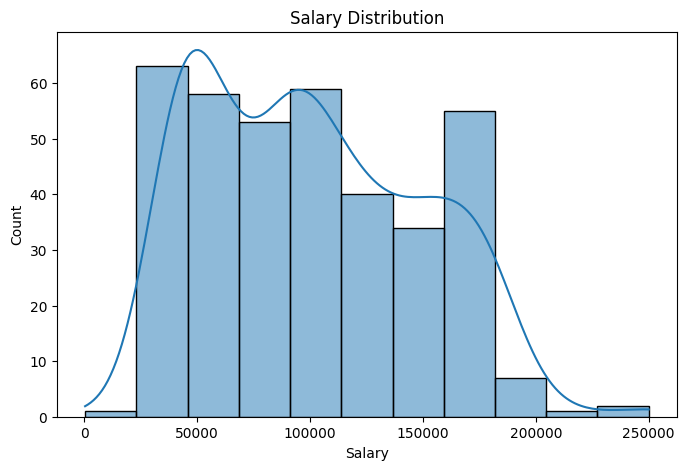

In [10]:
#EDA Analysis
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

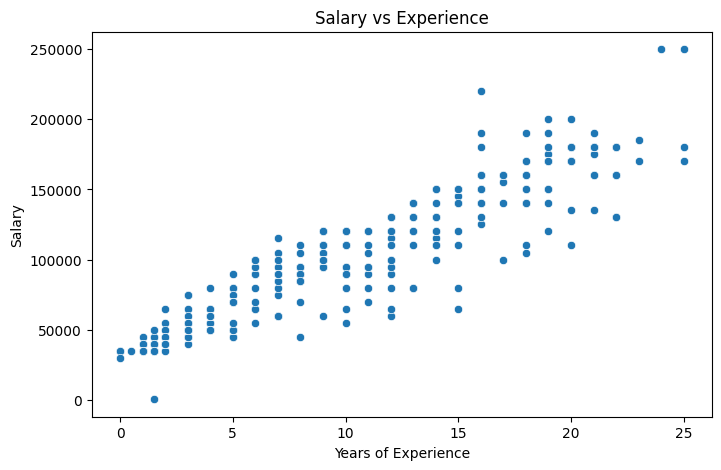

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Years of Experience', y='Salary', data=df)
plt.title("Salary vs Experience")
plt.show()

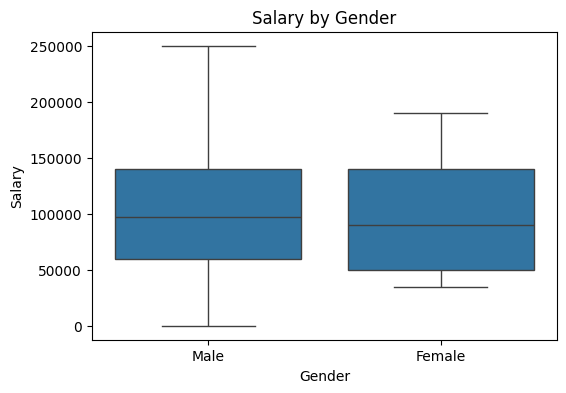

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Salary', data=df)
plt.title("Salary by Gender")
plt.show()

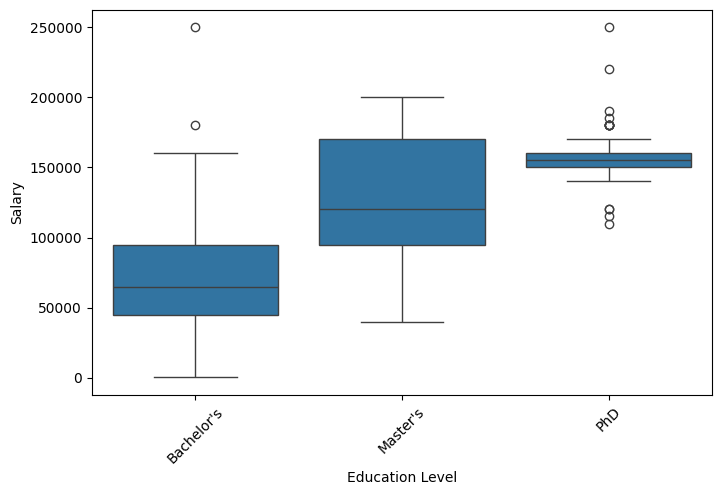

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.xticks(rotation=45)
plt.show()

In [14]:
#Data Preprocessing
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Education Level'] = le.fit_transform(df['Education Level'])
df['Job Title'] = le.fit_transform(df['Job Title'])

In [15]:
#Feature Selection
X = df.drop('Salary', axis=1)
y = df['Salary']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
#Build Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
#Prediction
y_pred = model.predict(X_test)

In [27]:
#Model evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 10928.921486231367
MSE: 249075656.4272197
RMSE: 15782.130921622076
R2 Score: 0.8961138207821872


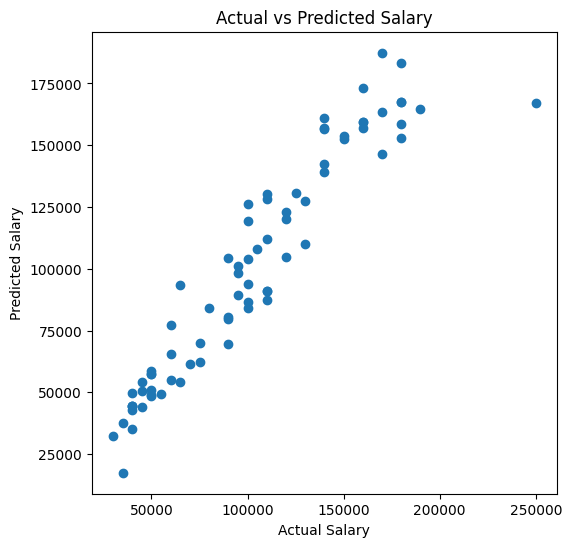

In [20]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

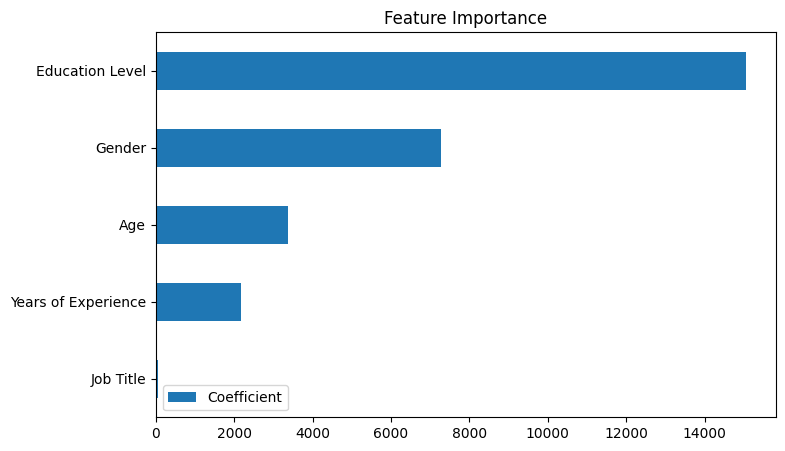

In [21]:
coeff = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

coeff.sort_values(by='Coefficient').plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

In [22]:
sample = [[30,1,2,10,5]]  
predicted_salary = model.predict(sample)
print("Predicted Salary:", predicted_salary)

Predicted Salary: [86001.33103945]


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Performance:")
print("R2 Score (Accuracy):", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Model Performance:
R2 Score (Accuracy): 0.8961138207821872
Mean Absolute Error: 10928.921486231367
Mean Squared Error: 249075656.4272197
Root Mean Squared Error: 15782.130921622076


In [24]:
accuracy = r2_score(y_test, y_pred) * 100
print("Model Accuracy:", accuracy, "%")

Model Accuracy: 89.61138207821871 %
